In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.loading_data.load_data import get_data
from src.stream_3.gower_distance import get_gower
from sklearn.preprocessing import StandardScaler
import umap 
import matplotlib.pyplot as plt


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = get_data()

DataFrame Cleaned Sucessfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'MEMS7_ALL',
       'year', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP',
       'motivc_POP', 'motivd_POP', 'WorkStat10', 'active'],
      dtype='str')
>>> Shape (86089, 17)
--------------------------
Columns NOT in Master.csv:
>>> ['nadults', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b', 'inclus_c', 'comm2', 'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4', 'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8']
Unhealthy Columns:
>>> ['motive_POP', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'worthw', 'indev', 'indevtry']


In [3]:
df = get_data()
categorical_cols = ['Gend3', 'Disab3', 'Eth7'] # VolAny is catgeorical but doesnt need to be encoded
continuous_cols = ['NSSEC5', 'Educ6', 'IMD10', 'nchild', 'Motiva_POP', 'motivb_POP','motivc_POP', 'motivd_POP', 'Age9', 'WorkStat10']
drop_cols = ['year', 'active', 'MEMS7_ALL']
df_2016 = df[df['year'] == '2016/17']
active, mems = df_2016['active'].values, df_2016['MEMS7_ALL'].values
df_2016_encoded_cats = pd.get_dummies(df_2016[categorical_cols], columns = categorical_cols)
df_2016_contin = df_2016[continuous_cols]
print(df_2016_encoded_cats.shape)
print(df_2016_contin.shape)


DataFrame Cleaned Sucessfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'MEMS7_ALL',
       'year', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP',
       'motivc_POP', 'motivd_POP', 'WorkStat10', 'active'],
      dtype='str')
>>> Shape (86089, 17)
--------------------------
Columns NOT in Master.csv:
>>> ['nadults', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b', 'inclus_c', 'comm2', 'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4', 'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8']
Unhealthy Columns:
>>> ['motive_POP', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'worthw', 'indev', 'indevtry']
(14656, 12)
(14656, 10)


In [4]:
scaler = StandardScaler()
df_2016_contin_scaled = scaler.fit_transform(df_2016_contin)
df_2016_combined = np.concatenate([df_2016_encoded_cats.values, df_2016_contin_scaled], axis=1)
print(df_2016_combined.shape)
reducer = umap.UMAP(random_state = 42)
emb = reducer.fit_transform(df_2016_combined)


(14656, 22)


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


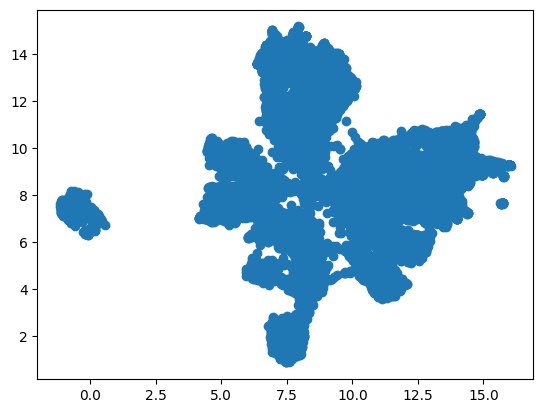

In [5]:
plt.scatter(emb[:,0], emb[:,1])

In [6]:
emb.shape

(14656, 2)

In [7]:
df = get_data()
categorical_cols = ['Gend3', 'Disab3',  'Eth7'] # VolAny is catgeorical but doesnt need to be encoded
continuous_cols = ['NSSEC5', 'Educ6', 'IMD10', 'nchild', 'Motiva_POP', 'motivb_POP','motivc_POP', 'motivd_POP','Age9', 'WorkStat10']
drop_cols = ['year', 'active', 'MEMS7_ALL']
df_2016 = df[df['year'] == '2016/17']
active, mems = df_2016['active'].values, df_2016['MEMS7_ALL'].values
cat_bool_mask = [True if c in categorical_cols else False for c in df_2016.columns]

DataFrame Cleaned Sucessfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'MEMS7_ALL',
       'year', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP',
       'motivc_POP', 'motivd_POP', 'WorkStat10', 'active'],
      dtype='str')
>>> Shape (86089, 17)
--------------------------
Columns NOT in Master.csv:
>>> ['nadults', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b', 'inclus_c', 'comm2', 'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4', 'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8']
Unhealthy Columns:
>>> ['motive_POP', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'worthw', 'indev', 'indevtry']


In [8]:
df_2016_clean = df_2016.drop(columns=(drop_cols))
print(df_2016_clean.columns)
gower_matrix = get_gower(categorical_cols, df_2016_clean)


Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP',
       'WorkStat10'],
      dtype='str')
Columns in df:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP',
       'WorkStat10'],
      dtype='str')
Categorical Features in Order:
['Gend3', 'Disab3', 'Eth7']
0 | True | Gend3
1 | True | Disab3
2 | False | Age9
3 | True | Eth7
4 | False | NSSEC5
5 | False | Educ6
6 | False | IMD10
7 | False | nchild
8 | False | VolAny
9 | False | Motiva_POP
10 | False | motivb_POP
11 | False | motivc_POP
12 | False | motivd_POP
13 | False | WorkStat10


In [12]:
emb = umap.UMAP(metric = 'precomputed', random_state = 42).fit_transform(gower_matrix)

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


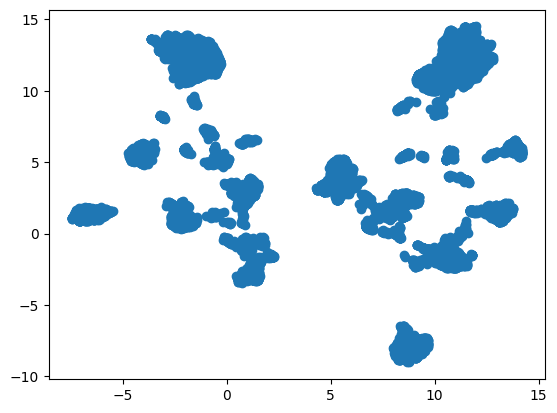

In [13]:
plt.scatter(emb[:,0], emb[:,1])